# Notebook 02: DICOM Volumes & 3D Spatial Geometry EDA
## RSNA Knee Abnormality Detection (KneeVision-AI)

This notebook examines the volumetric imaging characteristics of the DICOM series:
1. **DICOM Metadata Tag Extraction**: Slice thickness, pixel spacing, transfer syntaxes, and photometric interpretation.
2. **Variable Slice Depth ($D$) Analysis**: Quantifying slice counts per series (11 to 320 slices).
3. **3D Spatial Slice Ordering**: Sorting slices along the physical slice normal vector:
   $$\vec{n} = \vec{u}_{\text{row}} \times \vec{u}_{\text{col}}, \quad z_{\text{projected}} = \vec{p}_{\text{patient}} \cdot \vec{n}$$
4. **Intensity Normalization & VOI LUT Windowing**: Clipping percentiles and rescaling.
5. **Multi-Plane Volume Visualization**: Rendering Sagittal, Coronal, and Axial slice series.


In [1]:
import os
import sys

# Ensure repository root is in python path
for root_cand in ['.', '..', os.path.abspath(os.path.join(os.getcwd(), '..'))]:
    if os.path.exists(os.path.join(root_cand, 'src')):
        if os.path.abspath(root_cand) not in sys.path:
            sys.path.insert(0, os.path.abspath(root_cand))
        break

# Resolve DATA_DIR whether running from workspace root or notebooks/
DATA_DIR = None
for cand in [
    '../Datasets/rsna-knee-abnormality-detection',
    '../../Datasets/rsna-knee-abnormality-detection',
    os.path.expanduser('~/net/Datasets/rsna-knee-abnormality-detection'),
    '/home/AQ44130/net/Datasets/rsna-knee-abnormality-detection'
]:
    if os.path.exists(cand):
        DATA_DIR = os.path.abspath(cand)
        break

print(f"✓ Resolved DATA_DIR: {DATA_DIR}")

import glob
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.dicom_reader import read_dicom_slice, load_series_volume

TRAIN_SERIES_DIR = f'{DATA_DIR}/train_series'
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120


✓ Resolved DATA_DIR: /data/users/sukesh/Datasets/rsna-knee-abnormality-detection


## 1. Volumetric Header & Geometry Extraction (Sample 1500 Series)

In [2]:
# Inspect sample series across studies
study_folders = [f for f in os.listdir(TRAIN_SERIES_DIR) if os.path.isdir(os.path.join(TRAIN_SERIES_DIR, f))]
print(f"Total Study Folders in train_series: {len(study_folders):,}")

meta_records = []
for study in study_folders[:200]:
    study_path = os.path.join(TRAIN_SERIES_DIR, study)
    for series in os.listdir(study_path):
        series_path = os.path.join(study_path, series)
        if not os.path.isdir(series_path):
            continue
        dcm_files = [f for f in os.listdir(series_path) if f.endswith('.dcm')]
        if not dcm_files:
            continue
        
        try:
            dcm = pydicom.dcmread(os.path.join(series_path, dcm_files[0]), stop_before_pixels=True)
            meta_records.append({
                'StudyUID': study,
                'SeriesUID': series,
                'NumSlices': len(dcm_files),
                'Rows': dcm.Rows,
                'Columns': dcm.Columns,
                'PixelSpacing_X': float(dcm.PixelSpacing[0]) if hasattr(dcm, 'PixelSpacing') else np.nan,
                'PixelSpacing_Y': float(dcm.PixelSpacing[1]) if hasattr(dcm, 'PixelSpacing') else np.nan,
                'SliceThickness': float(dcm.SliceThickness) if hasattr(dcm, 'SliceThickness') else np.nan,
                'Photometric': getattr(dcm, 'PhotometricInterpretation', 'Unknown'),
            })
        except Exception:
            pass

df_meta = pd.DataFrame(meta_records)
print(f"Extracted metadata for {len(df_meta):,} series.")
display(df_meta.head())


Total Study Folders in train_series: 4,407


Extracted metadata for 1,125 series.


,StudyUID,SeriesUID,NumSlices,Rows,Columns,PixelSpacing_X,PixelSpacing_Y,SliceThickness,Photometric
0,1.2.826.0.1.3680043.8.498.75186274888329123179...,1.2.826.0.1.3680043.8.498.65522936023497924057...,30,320,320,0.500000,0.500000,4.00,MONOCHROME2
1,1.2.826.0.1.3680043.8.498.75186274888329123179...,1.2.826.0.1.3680043.8.498.44452671242744052346...,23,384,384,0.416667,0.416667,4.50,MONOCHROME2
2,1.2.826.0.1.3680043.8.498.75186274888329123179...,1.2.826.0.1.3680043.8.498.73107234960996327959...,25,384,384,0.416667,0.416667,4.00,MONOCHROME2
3,1.2.826.0.1.3680043.8.498.75186274888329123179...,1.2.826.0.1.3680043.8.498.61822035479910929541...,144,192,192,0.885417,0.885417,0.89,MONOCHROME2
4,1.2.826.0.1.3680043.8.498.89302191571937190529...,1.2.826.0.1.3680043.8.498.51118140251581704111...,25,512,512,0.322266,0.322266,3.50,MONOCHROME2


## 2. Slice Count & Spatial Resolution Distributions

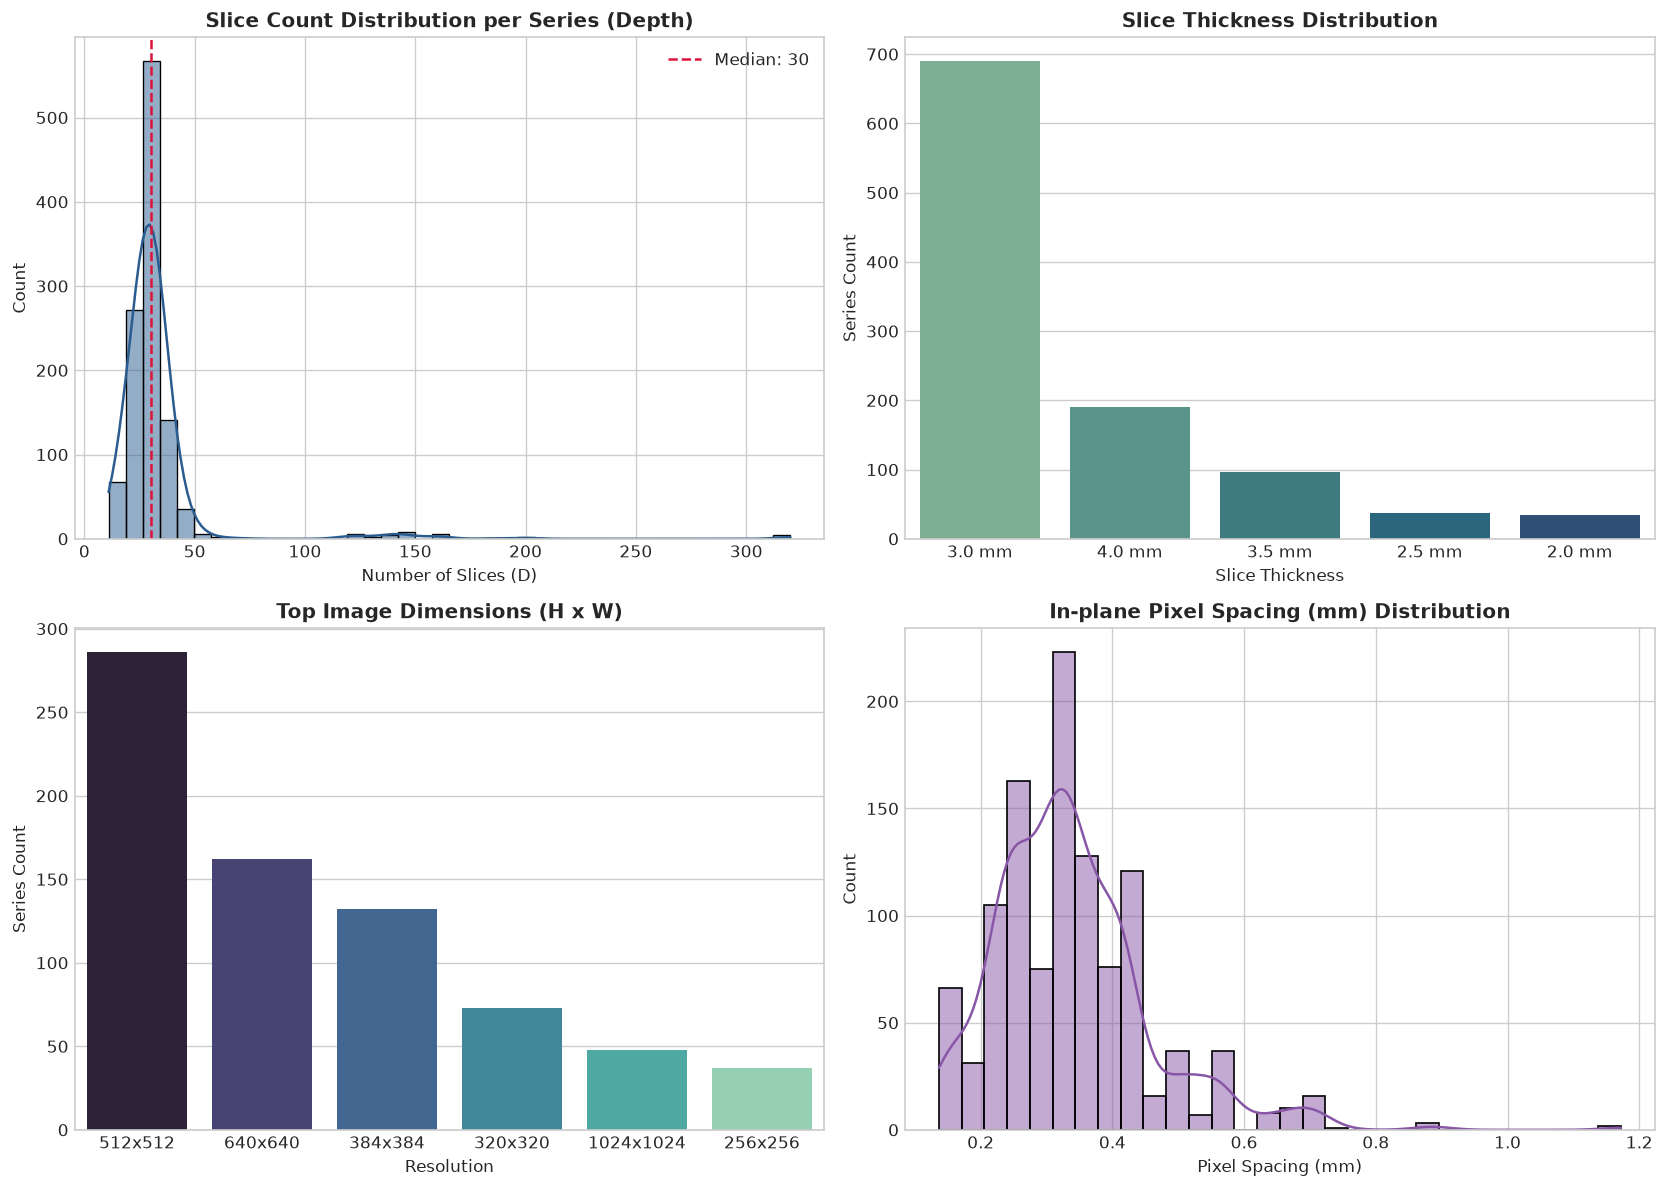

In [3]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# 1. Slice Counts
sns.histplot(df_meta['NumSlices'], bins=40, kde=True, color='#2b5c8f', ax=ax1)
ax1.set_title('Slice Count Distribution per Series (Depth)', fontweight='bold')
ax1.set_xlabel('Number of Slices (D)')
ax1.axvline(df_meta['NumSlices'].median(), color='crimson', linestyle='--', label=f"Median: {df_meta['NumSlices'].median():.0f}")
ax1.legend()

# 2. Slice Thickness
st_counts = df_meta['SliceThickness'].value_counts().head(5)
sns.barplot(x=st_counts.index.astype(str) + " mm", y=st_counts.values, hue=st_counts.index.astype(str), palette='crest', legend=False, ax=ax2)
ax2.set_title('Slice Thickness Distribution', fontweight='bold')
ax2.set_xlabel('Slice Thickness')
ax2.set_ylabel('Series Count')

# 3. Image Dimensions (Rows x Cols)
shape_series = df_meta['Rows'].astype(str) + "x" + df_meta['Columns'].astype(str)
top_shapes = shape_series.value_counts().head(6)
sns.barplot(x=top_shapes.index, y=top_shapes.values, hue=top_shapes.index, palette='mako', legend=False, ax=ax3)
ax3.set_title('Top Image Dimensions (H x W)', fontweight='bold')
ax3.set_xlabel('Resolution')
ax3.set_ylabel('Series Count')

# 4. In-Plane Pixel Spacing
sns.histplot(df_meta['PixelSpacing_X'].dropna(), bins=30, kde=True, color='#8856a7', ax=ax4)
ax4.set_title('In-plane Pixel Spacing (mm) Distribution', fontweight='bold')
ax4.set_xlabel('Pixel Spacing (mm)')

plt.tight_layout()
plt.show()


## 3. Spatial Slice Sorting along Patient Normal Vector vs Instance Number

In [4]:
# Select an example series to demonstrate 3D spatial sorting
sample_study = study_folders[0]
sample_study_path = os.path.join(TRAIN_SERIES_DIR, sample_study)
sample_series = os.listdir(sample_study_path)[0]
sample_series_path = os.path.join(sample_study_path, sample_series)

print(f"Loading Series: {sample_series_path}")
vol, metas = load_series_volume(sample_series_path, target_slices=32, normalize='minmax')
print(f"Loaded Volume Shape: {vol.shape} (Depth x Height x Width)")
print(f"Intensity Range: Min={vol.min():.3f}, Max={vol.max():.3f}, Mean={vol.mean():.3f}")


Loading Series: /data/users/sukesh/Datasets/rsna-knee-abnormality-detection/train_series/1.2.826.0.1.3680043.8.498.75186274888329123179129240384960518861/1.2.826.0.1.3680043.8.498.65522936023497924057245230631863949878
Loaded Volume Shape: (32, 320, 320) (Depth x Height x Width)
Intensity Range: Min=0.000, Max=1.000, Mean=0.151


## 4. Multi-Plane Volume Montage Visualization

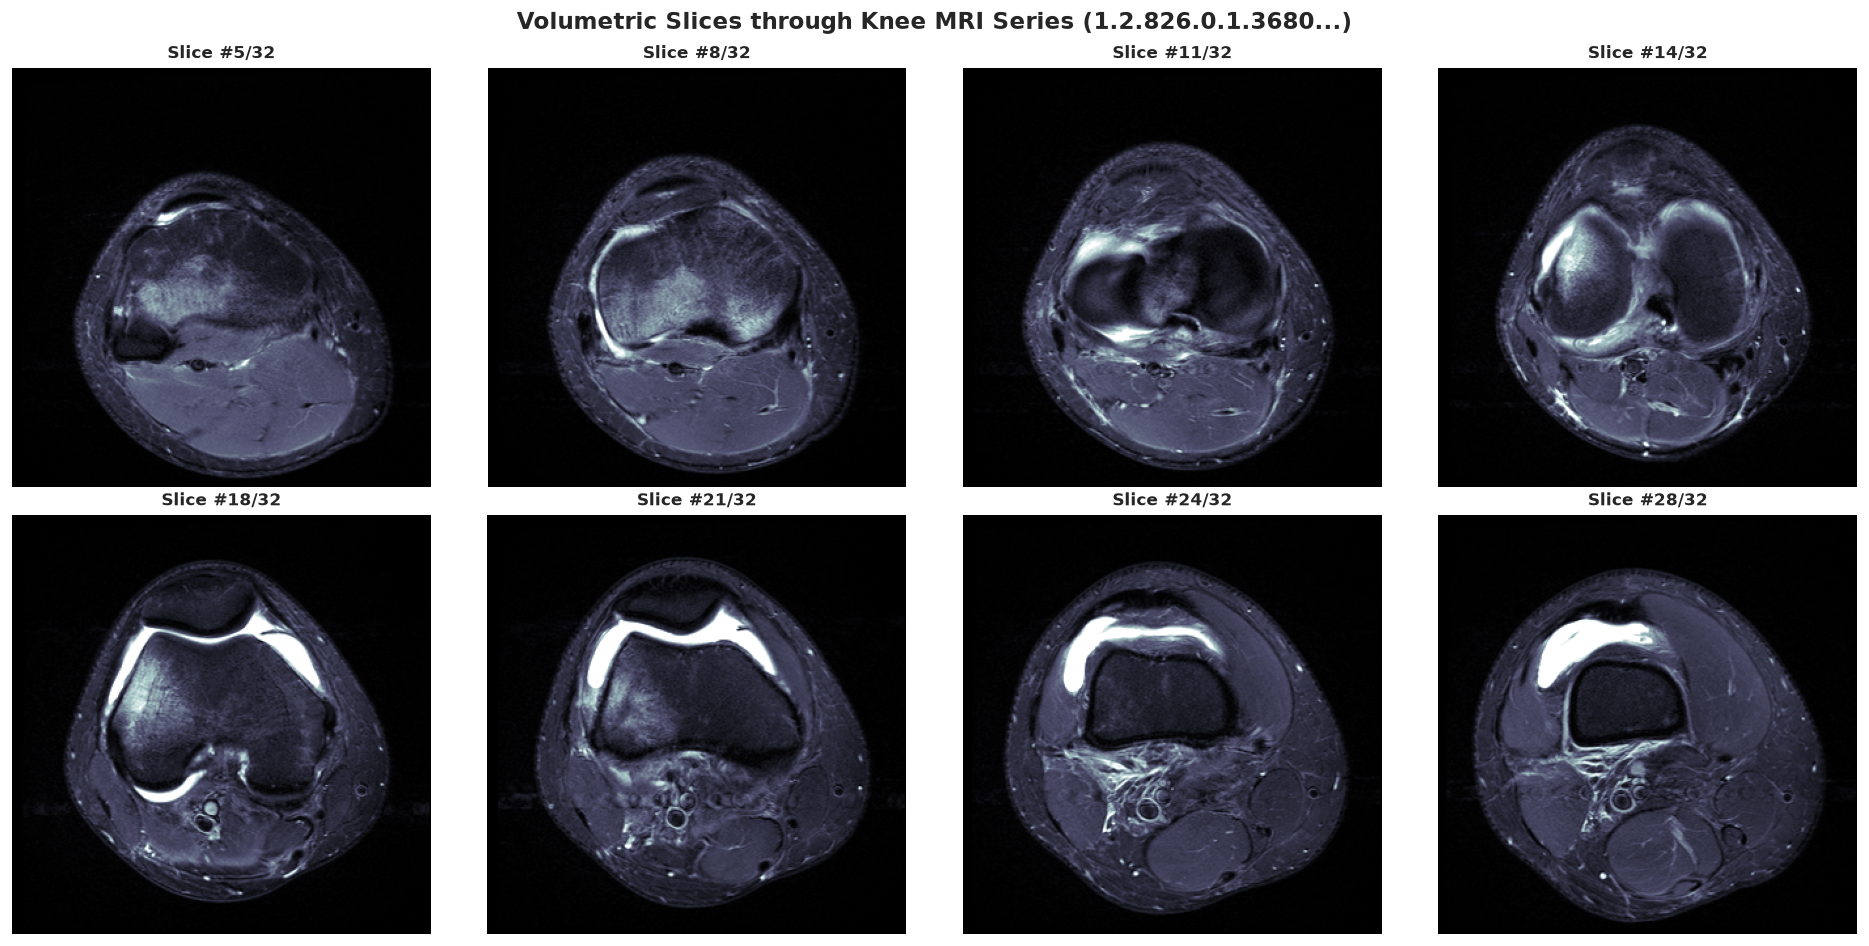

In [5]:
# Visualize an 8-slice montage through the volume
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
indices = np.linspace(4, vol.shape[0] - 5, 8).astype(int)

for idx, ax in zip(indices, axes.flatten()):
    ax.imshow(vol[idx], cmap='bone')
    ax.set_title(f"Slice #{idx+1}/{vol.shape[0]}", fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle(f"Volumetric Slices through Knee MRI Series ({sample_series[:16]}...)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Tri-Planar Study Visualization (Sagittal + Coronal + Axial)

,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
19207,1.2.826.0.1.3680043.8.498.75186274888329123179...,1.2.826.0.1.3680043.8.498.44452671242744052346...,0,0,Coronal
19208,1.2.826.0.1.3680043.8.498.75186274888329123179...,1.2.826.0.1.3680043.8.498.61822035479910929541...,1,1,Sagittal
19209,1.2.826.0.1.3680043.8.498.75186274888329123179...,1.2.826.0.1.3680043.8.498.65522936023497924057...,1,1,Axial
19210,1.2.826.0.1.3680043.8.498.75186274888329123179...,1.2.826.0.1.3680043.8.498.73107234960996327959...,0,0,Sagittal


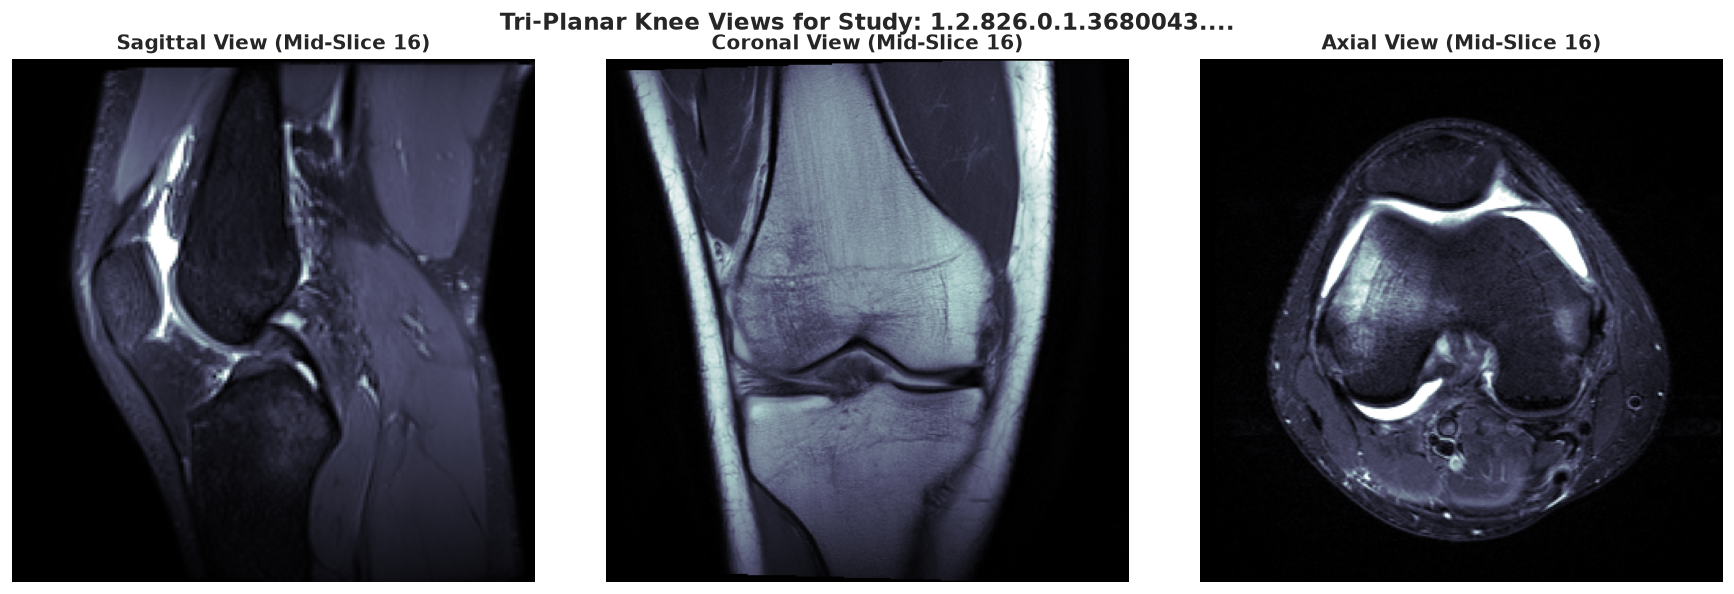

In [6]:
train_series_csv = pd.read_csv(f"{DATA_DIR}/train_series.csv")
study_series_df = train_series_csv[train_series_csv['StudyInstanceUID'] == sample_study]
display(study_series_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
planes = ['Sagittal', 'Coronal', 'Axial']

for i, plane in enumerate(planes):
    matching = study_series_df[study_series_df['Anatomical_Plane'] == plane]
    if len(matching) > 0:
        ser_uid = matching.iloc[0]['SeriesInstanceUID']
        ser_dir = os.path.join(TRAIN_SERIES_DIR, sample_study, ser_uid)
        if os.path.exists(ser_dir):
            p_vol, _ = load_series_volume(ser_dir, target_slices=32, normalize='minmax')
            mid_idx = p_vol.shape[0] // 2
            axes[i].imshow(p_vol[mid_idx], cmap='bone')
            axes[i].set_title(f"{plane} View (Mid-Slice {mid_idx})", fontweight='bold')
    axes[i].axis('off')

plt.suptitle(f"Tri-Planar Knee Views for Study: {sample_study[:20]}...", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
